In [21]:
# STEP 1: DATA LOADING
# Load raw grocery transaction data (each row = one item purchased by one customer on one date)

import pandas as pd
df= pd.read_csv('Groceries_dataset.csv')
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [22]:
# STEP 2: DATA QUALITY CHECK

df.shape
df.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

In [23]:
# STEP 3: BUILD TRANSACTIONS
# Group rows into actual "shopping trips" — one transaction = one customer's
# purchases on one date, combined into a list of items

transactions= df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)
transactions.shape
transactions.head(10)

Member_number  Date      
1000           15-03-2015    [sausage, whole milk, semi-finished bread, yog...
               24-06-2014                    [whole milk, pastry, salty snack]
               24-07-2015                       [canned beer, misc. beverages]
               25-11-2015                          [sausage, hygiene articles]
               27-05-2015                           [soda, pickled vegetables]
1001           02-05-2015                                  [frankfurter, curd]
               07-02-2014                    [sausage, whole milk, rolls/buns]
               12-12-2014                                   [whole milk, soda]
               14-04-2015                                  [beef, white bread]
               20-01-2015              [frankfurter, soda, whipped/sour cream]
Name: itemDescription, dtype: object

In [25]:
# STEP 4: TRANSACTION ENCODING
# Convert each transaction into a True/False row across all 167 unique products —
# the format Apriori needs to work with

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

df_encoded.shape
df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [26]:
# STEP 5: FREQUENT ITEMSETS (APRIORI)
# Find items/combinations that appear in at least 0.3% of transactions

from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_encoded, min_support=0.003, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

frequent_itemsets.head(15)

,support,itemsets
108,0.157923,frozenset({whole milk})
67,0.122101,frozenset({other vegetables})
82,0.110005,frozenset({rolls/buns})
91,0.097106,frozenset({soda})
109,0.085879,frozenset({yogurt})
83,0.069572,frozenset({root vegetables})
101,0.067767,frozenset({tropical fruit})
7,0.060683,frozenset({bottled water})
86,0.060349,frozenset({sausage})
22,0.053131,frozenset({citrus fruit})


In [27]:
# STEP 6: CHECK MULTI-ITEM COMBINATIONS SPECIFICALLY
# Filter out single items to see genuine product pairs

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets[frequent_itemsets['length'] >= 2].sort_values('support', ascending=False)

,support,itemsets,length
172,0.014837,"frozenset({other vegetables, whole milk})",2
192,0.013968,"frozenset({whole milk, rolls/buns})",2
209,0.011629,"frozenset({whole milk, soda})",2
215,0.011161,"frozenset({whole milk, yogurt})",2
165,0.010559,"frozenset({other vegetables, rolls/buns})",2
...,...,...,...
155,0.003074,"frozenset({whole milk, hamburger meat})",2
186,0.003074,"frozenset({pork, yogurt})",2
160,0.003007,"frozenset({rolls/buns, newspapers})",2
157,0.003007,"frozenset({rolls/buns, margarine})",2


In [28]:
# STEP 7: ASSOCIATION RULES
# Generate "if A then B" rules with support, confidence, and lift.
# Lift > 1 means the pairing is a genuine association, not just coincidence
# from two individually popular items

from mlxtend.frequent_patterns import association_rules
rules= association_rules(frequent_itemsets, metric="lift", min_threshold=0.5)
rules= rules.sort_values('lift', ascending=False)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)


,antecedents,consequents,support,confidence,lift
173,frozenset({sausage}),frozenset({bottled beer}),0.003342,0.055371,1.222000
172,frozenset({bottled beer}),frozenset({sausage}),0.003342,0.073746,1.222000
71,frozenset({frankfurter}),frozenset({other vegetables}),0.005146,0.136283,1.116150
70,frozenset({other vegetables}),frozenset({frankfurter}),0.005146,0.042146,1.116150
49,frozenset({sausage}),frozenset({yogurt}),0.005748,0.095238,1.108986
48,frozenset({yogurt}),frozenset({sausage}),0.005748,0.066926,1.108986
180,frozenset({pastry}),frozenset({sausage}),0.003208,0.062016,1.027617
181,frozenset({sausage}),frozenset({pastry}),0.003208,0.053156,1.027617
44,frozenset({soda}),frozenset({sausage}),0.005948,0.061253,1.014975
45,frozenset({sausage}),frozenset({soda}),0.005948,0.098560,1.014975


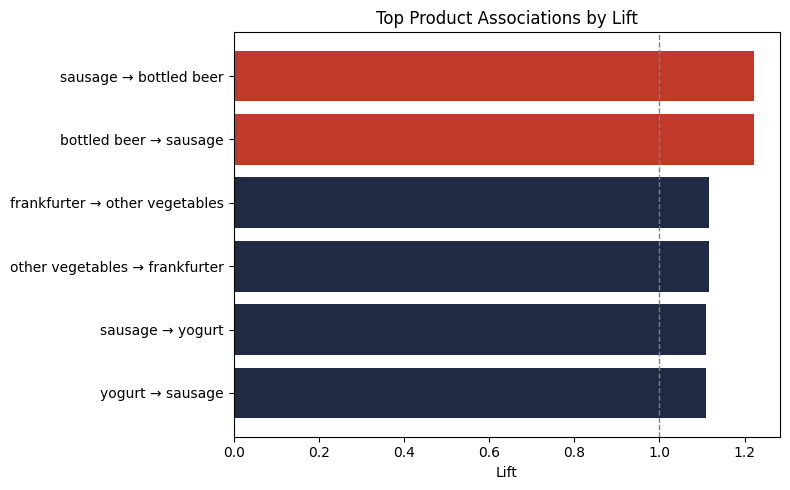

In [29]:
# STEP 8: VISUALIZATION
# Bar chart of the top 6 rules by lift — highlights the strongest, most
# actionable cross-sell pairing in red

import matplotlib.pyplot as plt
top_rules= rules[['antecedents', 'consequents', 'lift']].head(6).copy()
top_rules['pair']= top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' → ' + top_rules['consequents'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(8,5))
colors= ['#C0392B' if l == top_rules['lift'].max() else '#1F2A44' for l in top_rules['lift']]
plt.barh(top_rules['pair'][::-1], top_rules['lift'][::-1], color=colors[::-1])
plt.axvline(1.0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Lift')
plt.title('Top Product Associations by Lift')
plt.tight_layout()
plt.show()